In [35]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

# start 8:14pm

# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [36]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/verdanteye", token=api_key)

Loaded as API: https://verdantintel-verdanteye.hf.space


# Helper Function

In [37]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    answer = ast.literal_eval(answer)

    return answer

# Searching for Data

In [38]:
question = 'what has been seen in the last six hours?'

answer = ask_api(client, question)
len(answer)

1463

In [39]:
answer[0]

{'claim': 'Details about a news event.',
 'url': 'https://ae.headtopics.com/news/15931585160815971895-83916893',
 'domain': 'headtopics.com',
 'url_domain': 'ae.headtopics.com',
 'date_added': '2026-05-29 16:33:00'}

In [40]:
df = pd.DataFrame(answer)
df['date_added'] = pd.to_datetime(df['date_added'], utc=True)
df['date_added'] = df['date_added'].dt.tz_convert('America/Los_Angeles') # put into my timezone
df.sort_values('date_added', ascending=False, inplace=True)
df.head()

,claim,url,domain,url_domain,date_added
0,Details about a news event.,https://ae.headtopics.com/news/159315851608159...,headtopics.com,ae.headtopics.com,2026-05-29 09:33:00-07:00
13,The government confirms a new social welfare p...,https://ie.headtopics.com/news/government-conf...,headtopics.com,ie.headtopics.com,2026-05-29 09:33:00-07:00
24,Woolworths increases security at all stores af...,https://za.headtopics.com/news/woolworths-incr...,headtopics.com,za.headtopics.com,2026-05-29 09:33:00-07:00
23,A peaceful protest in Cape Town attracted 500 ...,https://za.headtopics.com/news/peaceful-protes...,headtopics.com,za.headtopics.com,2026-05-29 09:33:00-07:00
22,A guardian was handed two life terms for rapin...,https://za.headtopics.com/news/guardian-handed...,headtopics.com,za.headtopics.com,2026-05-29 09:33:00-07:00


In [41]:
drop_terms = [
    'news article', 'news topic', 'status update', 'event', 'ticket', 'not identified', 
    'not enough information', 'news update', 'no specific claim', 'no claim', 'unspecified news',
    'article related to', 'claim related to', 'claim not specified', 'recent news post', 'a specific report',
    'lacks specific claim', 'unclear claim', 'unspecified incident', 'no claims available',
    'news story', 'news report', 'news post', 'news item', 'current news', 'unknown claim', 'uncertain claim',
    'video clip is available', 'no clear claim', 'claim not discernible', 'not specified', 'unspecified', 
    'claim is unclear', 'news related', 'specific news', 'unspecified content'
]

pattern = '|'.join(drop_terms)

df = df[~df['claim'].str.contains(pattern, case=False, na=False)]

In [42]:
#df.to_csv('claim_edgelist.csv', header=True, index=False)

In [43]:
df.tail() # six hours

,claim,url,domain,url_domain,date_added
1458,Celtic fans are frightened and anxious,https://www.dailyrecord.co.uk/sport/football/f...,dailyrecord.co.uk,dailyrecord.co.uk,2026-05-29 03:39:50-07:00
1459,"A mother was found dead near an asylum center,...",https://modernity.news/2026/05/29/mother-found...,whatfinger.com,modernity.news,2026-05-29 03:38:43-07:00
1460,A Pennsylvania man has been charged with assau...,https://www.alexjoneslive.com/2026/05/29/penns...,whatfinger.com,alexjoneslive.com,2026-05-29 03:38:43-07:00
1461,Police raided schools and arrested 16 employee...,https://www.alexjoneslive.com/2026/05/29/polic...,whatfinger.com,alexjoneslive.com,2026-05-29 03:38:43-07:00
1462,A suspect involved in a plot to attack a Taylo...,https://abc7chicago.com/post/suspect-taylor-sw...,abc7chicago.com,abc7chicago.com,2026-05-29 03:37:43-07:00


In [44]:
df.shape

(1107, 5)

# Clustering

Clustering is useful for seeing the kinds of things that are happening. If you want to do trend analysis, start with clustering or filtering. You will want to have clustering in your skillset/toolset. Here is my graph+nlp approach, my own approach.

Tweak the similarity threshold to get what you want. 1 is exact match. 0 is no match. 0.5-0.8 is typically pretty sweet, but it depends on what you are doing. Sometimes lower is useful. Sometimes very high is useful. Be thoughtful about what you are trying to do and it will make sense. Ask me if you would like to learn more.

In [45]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [46]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

In [47]:
df.head()

,claim,url,domain,url_domain,date_added
13,The government confirms a new social welfare p...,https://ie.headtopics.com/news/government-conf...,headtopics.com,ie.headtopics.com,2026-05-29 09:33:00-07:00
24,Woolworths increases security at all stores af...,https://za.headtopics.com/news/woolworths-incr...,headtopics.com,za.headtopics.com,2026-05-29 09:33:00-07:00
23,A peaceful protest in Cape Town attracted 500 ...,https://za.headtopics.com/news/peaceful-protes...,headtopics.com,za.headtopics.com,2026-05-29 09:33:00-07:00
22,A guardian was handed two life terms for rapin...,https://za.headtopics.com/news/guardian-handed...,headtopics.com,za.headtopics.com,2026-05-29 09:33:00-07:00
21,A teenager was seriously injured in a stabbing...,https://uk.headtopics.com/news/teenager-seriou...,headtopics.com,uk.headtopics.com,2026-05-29 09:33:00-07:00


In [48]:
df['cluster'] = cluster_text(df['claim'], similarity_threshold=0.4) # reducing to capture broader topics
df.head()

,claim,url,domain,url_domain,date_added,cluster
13,The government confirms a new social welfare p...,https://ie.headtopics.com/news/government-conf...,headtopics.com,ie.headtopics.com,2026-05-29 09:33:00-07:00,0
24,Woolworths increases security at all stores af...,https://za.headtopics.com/news/woolworths-incr...,headtopics.com,za.headtopics.com,2026-05-29 09:33:00-07:00,1
23,A peaceful protest in Cape Town attracted 500 ...,https://za.headtopics.com/news/peaceful-protes...,headtopics.com,za.headtopics.com,2026-05-29 09:33:00-07:00,2
22,A guardian was handed two life terms for rapin...,https://za.headtopics.com/news/guardian-handed...,headtopics.com,za.headtopics.com,2026-05-29 09:33:00-07:00,3
21,A teenager was seriously injured in a stabbing...,https://uk.headtopics.com/news/teenager-seriou...,headtopics.com,uk.headtopics.com,2026-05-29 09:33:00-07:00,4


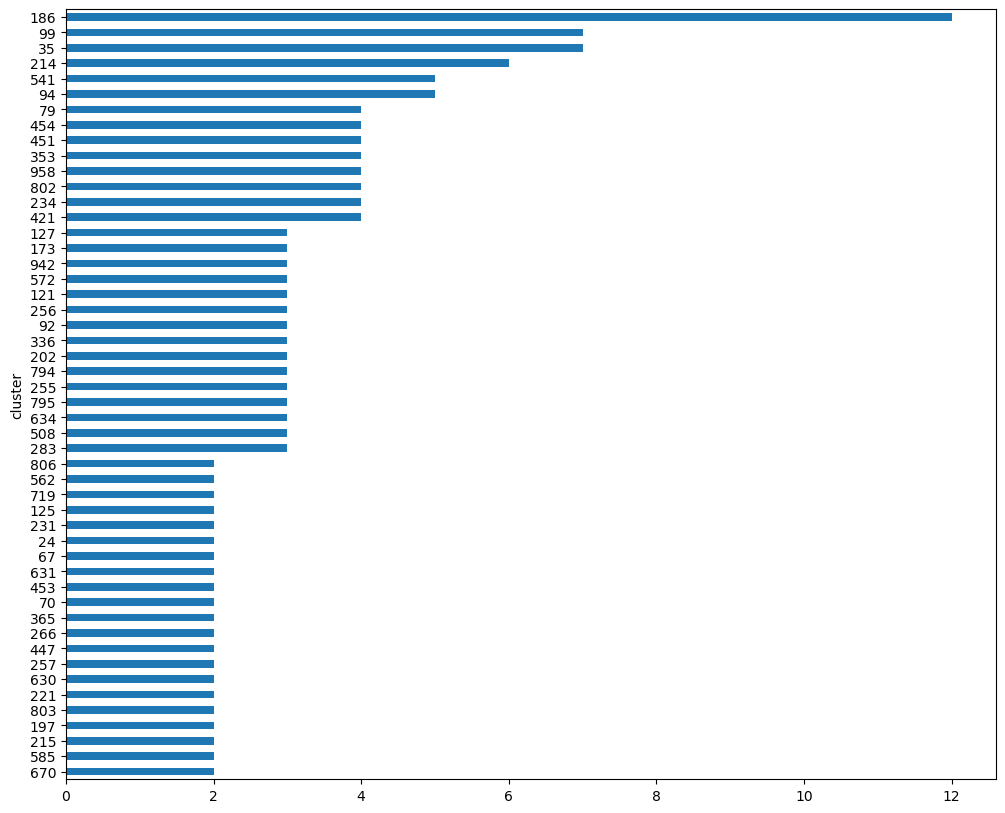

In [49]:
df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [50]:
top_clusters = df['cluster'].value_counts().index.values
top_clusters

array([186,  99,  35, 214, 541,  94,  79, 454, 451, 353, 958, 802, 234,
       421, 127, 173, 942, 572, 121, 256,  92, 336, 202, 794, 255, 795,
       634, 508, 283, 806, 562, 719, 125, 231,  24,  67, 631, 453,  70,
       365, 266, 447, 257, 630, 221, 803, 197, 215, 585, 670, 200, 432,
       638, 105, 372, 561, 187, 403, 495, 629, 708,  41, 129, 358, 251,
       543,  30, 307, 553, 131, 699, 713, 555, 183, 672, 654, 655, 647,
       651, 646, 652, 671, 653, 645, 648, 667, 669, 656, 668, 649, 666,
       657, 658, 665, 650, 664, 659, 660, 663, 662, 661,   0, 685, 673,
       717, 704, 705, 706, 707, 709, 710, 711, 712, 714, 715, 716, 718,
       702, 720, 721, 722, 723, 724, 725, 726, 727, 728, 729, 730, 703,
       701, 674, 686, 675, 676, 677, 678, 679, 680, 681, 682, 683, 684,
       643, 687, 700, 688, 689, 690, 691, 692, 693, 694, 695, 696, 697,
       698, 644, 622, 642, 560, 546, 547, 548, 549, 550, 551, 552, 554,
       556, 557, 558, 559, 563, 641, 564, 565, 566, 567, 568, 56

In [51]:
for cluster in top_clusters:
    
    print('cluster: {}'.format(cluster))
    
    cluster_data = df[df['cluster']==cluster].head(20)['claim'].values
    print(cluster_data)
    
    print()

cluster: 186
['A bus accident in Virginia resulted in 5 deaths and 34 injuries.'
 'Bus crash on I-95 in Virginia resulted in 5 deaths and dozens injured'
 'A bus accident in Virginia resulted in deaths.'
 'Claim about a bus crash resulting in fatalities and injuries in Virginia.'
 'A bus accident in Virginia resulted in 5 deaths and 34 injuries.'
 'A bus accident in Virginia has resulted in 5 deaths and 34 injuries.'
 'A bus crash on I-95 in Virginia resulted in 5 fatalities and multiple injuries.'
 'A bus crash on I-95 in Virginia results in 5 deaths and dozens injured.'
 'A bus crash in Virginia resulted in deaths on Interstate 95.'
 'A bus hit cars in Virginia, resulting in 5 deaths and 34 injuries according to state police.'
 'A bus crash on Interstate 95 in Virginia occurred.'
 'A crash on I-95 southbound in Stafford County resulted in 5 deaths and dozens of injuries.']

cluster: 99
['A Ghanaian mother and her child are detained despite having valid visas.'
 'Ghanaian mother and c

['Report on a fire accident at Penn Station impacting train services in New Jersey with details on the death toll']

cluster: 565
['Four climbers on Mount McKinley require rescue.']

cluster: 566
['Arkansas has implemented a miscarriage abortion ban.']

cluster: 567
['The failed surplus deal negatively affects Wisconsin kids.']

cluster: 568
['A man was shot in the head during a fight in Southeast Las Vegas.']

cluster: 569
['Amtrak fire leads to suspension of services at Penn Station']

cluster: 570
['Dramatic rescue of students captured']

cluster: 571
['Conditions contributed to climbers falling from mountain']

cluster: 573
['Workshop for creative audio description']

cluster: 574
['Recovery of remains of chemical tank workers']

cluster: 575
['Rail car fire injures 5 and disrupts train service']

cluster: 576
["A member of Texas' 10 most wanted has been captured following a police chase in Austin."]

cluster: 545
['Colorblind (TX) is performing at Roseland Theater.']

cluster: 544

['A study by New America discusses the quality of child care and the time spent on it.']

cluster: 951
['Millions of people in the UK are facing new financial challenges.']

cluster: 952
['A large junkyard fire occurred at an EMR recycling plant in Camden, New Jersey.']

cluster: 953
["Sam Aston from Coronation Street has announced that his wife is pregnant with their fourth child and shared details about the unborn baby's ultrasound."]

cluster: 954
['A 16-year-old drowned while dreaming of becoming a doctor, with implications of the dangers of open water during a heatwave.']

cluster: 955
['Mount Saint Elias is performing at The Birdhouse.']

cluster: 956
["6lack is scheduled to perform at McMenamin's Crystal Ballroom."]

cluster: 957
['Merwulf is performing at Second Chance Records LLC.']

cluster: 960
['Skip the Needle is performing at Radness Ensues.']

cluster: 915
['A Black Hawk helicopter assisted in a takedown operation in the U.S.']

cluster: 961
["Galacticnorcinerator will b

["Grab's digital boost turns Sabah's Kaamatan festivities"]

cluster: 259
['Rescue efforts underway for trapped people in flooded Laos']

cluster: 260
['UN calls for stricter digital safeguards for children']

cluster: 261
['FCTA threatens sanctions over illegal facility use']

cluster: 262
['Lagos demolishes 17 illegal structures, seals 52 buildings']

cluster: 263
['NSIB probes Bonny ship collision after oil spill']

cluster: 233
['The article discusses the complex origins of the Lanterman-Petris-Short Act.']

cluster: 230
['A teenager released by ICE wishes to remain in the U.S.']

cluster: 198
['Police officers who shot a knife-wielding man have been cleared by the watchdog.']

cluster: 229
['A father and police are involved in a case regarding the brutal murder of a mother by her son.']

cluster: 199
['Claim about a legal case advancing against a man accused of murder in Milford.']

cluster: 201
['Claim relates to a scheduled dance performance.']

cluster: 203
['A TV star has tran

["The article discusses cancellations related to a concert called 'Freedom 250'."]

cluster: 93
["House lawmakers are seeking answers regarding the Southern Poverty Law Center's congressional review."]

cluster: 264
['Senator Estrada posts bail and surrenders to anti-graft authorities']

cluster: 265
['Simex on robbery-hostage situation at mall']

cluster: 267
['Eight students detained on suspicion of causing fire']

cluster: 419
['A story about a mother who parties while her kids have access to alcohol.']

cluster: 422
['Crews have recovered the remains of workers from a chemical tank incident in Washington.']

cluster: 423
['A party bus caught fire in Bridgewater, requiring efforts from volunteer firefighters to extinguish the blaze.']

cluster: 424
['A data problem between Central and South is unresolved, causing issues for the district.']

cluster: 425
['A driver involved in a fatal wrong-way crash has been charged.']

cluster: 426
["Exploring the intersection of motherhood and man

['Rumer Willis accuses her ex of domestic violence and emotional abuse during a custody battle']

cluster: 361
['Firefighters responded to a fire at a waste management center near Magna.']

cluster: 362
['Report on a bus accident involving children in Mazara del Vallo']

cluster: 363
['Drought and wildfires in Florida could worsen']

cluster: 364
['Search underway for four climbers who fell']

cluster: 366
["A former sheriff's office sergeant has been indicted on additional theft charges."]

cluster: 367
['A charity flow class is being held at the Jefferson Center in support of Mental Health Month.']

cluster: 368
['Three minors were arrested for fatally stabbing a man during Eid celebrations in Delhi.']

cluster: 369
['Six people were killed when a part of a bridge under construction collapsed during a storm in Hamirpur.']

cluster: 370
['The US Justice Department is seeking personal information of users critical of government deportation efforts.']

cluster: 371
['California is suing

In [52]:
# end 8:15pm